In [1]:
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.io import wavfile
import joblib
import os

import sys
import glob
import torch

sys.path.append('../utils/')
sys.path.append('../src/model/')

sys.path.append("/om2/user/bjmedina/auditory-memory/memory/")

from utils.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir
from utils.dprime import recompute_dprime_by_isi_per_subject
from utils.reliability import compute_itemwise_split_half_reliability

import DistanceMemoryModel
import encoders

sys.path.append('/om2/user/bjmedina/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params

import json
import glob
import sys
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from scipy.stats import norm
from collections import defaultdict

def collect_representations(encoding_model, sound_list):
    """
    Encode a list of sound file paths using the given model.

    Args:
        encoding_model: a callable that takes a sound path (str) and returns a representation.
        sound_list (list of str): List of paths to audio files.

    Returns:
        np.ndarray: Array of shape (n_sounds, encoding_dim).
    """
    reps = []
    for sound_path in sound_list:
        try:
            with torch.no_grad():
                rep = encoding_model(sound_path).squeeze(0).cpu().numpy()
            reps.append(rep)
        except AttributeError:
            continue
    return np.stack(reps)

def fit_gmm_prior(encoded_reps, n_components_range=(2, 20), reduce_dims_to=50, use_pca=True, zscore=True, seed=42):
    """
    Fit a GMM to encoded representations with optional z-scoring and PCA.

    Args:
        encoded_reps (ndarray): Array of shape (n_samples, n_features).
        n_components_range (tuple): Range of GMM components to search (min, max).
        reduce_dims_to (int or None): Reduce to this number of dims with PCA.
        use_pca (bool): Whether to apply PCA.
        zscore (bool): Whether to z-score representations first.
        seed (int): Random seed for reproducibility.

    Returns:
        gmm (GaussianMixture): Fitted GMM object.
        transform_fn (function): Function that maps new encodings to GMM input space.
    """
    X = encoded_reps.copy()

    if zscore:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    else:
        scaler = None

    if use_pca:
        pca = PCA(n_components=min(reduce_dims_to, X.shape[1]), random_state=seed)
        X = pca.fit_transform(X)
    else:
        pca = None

    # Select best GMM via BIC
    best_gmm = None
    lowest_bic = np.inf
    for n_components in range(n_components_range[0], n_components_range[1] + 1):
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed)
        gmm.fit(X)
        bic = gmm.bic(X)
        if bic < lowest_bic:
            lowest_bic = bic
            best_gmm = gmm

    def transform_fn(new_reps):
        new_X = new_reps.copy()
        if zscore:
            new_X = scaler.transform(new_X)
        if use_pca:
            new_X = pca.transform(new_X)
        return new_X

    return best_gmm, transform_fn

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# grabbing example list of sound
sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_p1/*wav")
texture_list = sounds_list

ALL_SOUNDS = glob.glob("/om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_*/*wav")
print(len(ALL_SOUNDS))

cuda
2008997


In [3]:
texture_model = encoders.AudioTextureEncoder(
    statistics_dict=statistics_dict,
    model_params=model_params,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device=device
)

In [4]:
zscore_projector = encoders.ZScoreSpace(texture_model, device=device)
zscore_projector.fit(ALL_SOUNDS[:2000])

a, b = zscore_projector.mean, zscore_projector.std

Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-1hPNpfM9p4.wav: Sound too short after resampling: 24280 < 40000


In [5]:
zscore_projector = encoders.ZScoreSpace(texture_model, device=device)
zscore_projector.fit(ALL_SOUNDS[:10000])

c, d = zscore_projector.mean, zscore_projector.std

Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-1hPNpfM9p4.wav: Sound too short after resampling: 24280 < 40000
Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-3TA9Fns4rA.wav: Sound too short after resampling: 0 < 40000


In [11]:
np.mean(c-a, axis=0)

-0.0039922604

In [12]:
np.mean(d-b, axis=0)

-0.0010782809

In [15]:
reps = collect_representations(zscore_projector, ALL_SOUNDS[5000:9000])

In [16]:
def plot_pca_variance(X, max_components=100):
    """
    Plot the variance explained by the top principal components.

    Args:
        X (np.ndarray): Input data, already z-scored.
        max_components (int): Max number of components to show.
    """
    pca = PCA(n_components=min(max_components, X.shape[1]))
    pca.fit(X)
    
    var_ratio = pca.explained_variance_ratio_
    cum_var = var_ratio.cumsum()
    
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(var_ratio) + 1), cum_var, marker='o', alpha=0.5)
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Variance Explained")
    plt.title("PCA Variance Explained")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pca

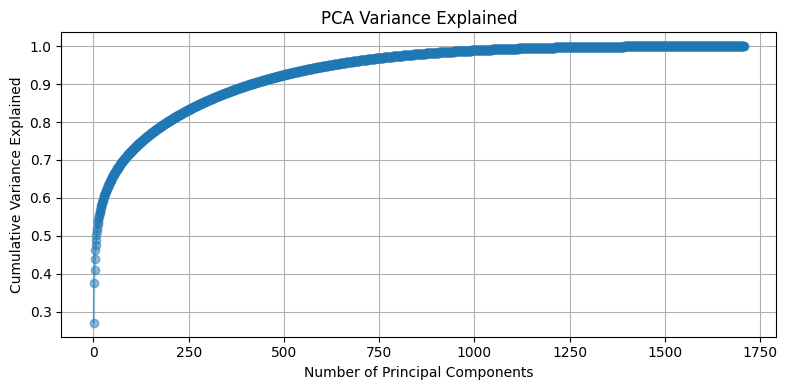

In [17]:
# Now plot variance explained
pca = plot_pca_variance(reps, max_components=min(1707, len(reps)))

In [18]:
def plot_pca_generalization(pca, X_test, label_train="Train", label_test="Test"):
    """
    Plot cumulative variance explained in train vs test sets using same PCA basis.

    Args:
        pca (PCA): Trained PCA object.
        X_test (np.ndarray): Z-scored test set in same space as train.
        label_train (str): Label for training data (legend).
        label_test (str): Label for test data (legend).
    """
    # Variance explained on training data (from pca object)
    var_train = pca.explained_variance_ratio_
    cum_train = var_train.cumsum()
    
    # Project test data
    X_test_proj = pca.transform(X_test)
    var_test = X_test_proj.var(axis=0) / X_test_proj.var(axis=0).sum()
    cum_test = var_test.cumsum()
    
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(cum_train) + 1), cum_train, label=label_train, alpha=0.7)
    plt.plot(range(1, len(cum_test) + 1), cum_test, label=label_test, alpha=0.7)
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Variance Explained")
    plt.title("PCA Generalization: Train vs Test Variance")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
test_reps = collect_representations(zscore_projector, sounds_list)

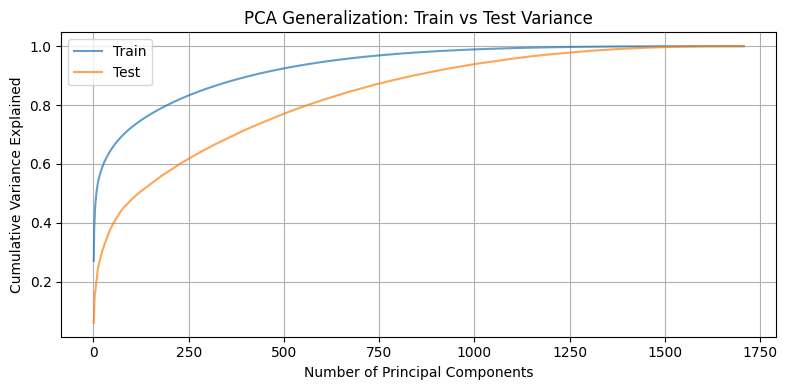

In [20]:
plot_pca_generalization(pca, test_reps, label_train="Train", label_test="Test")

In [21]:
X_test_proj = pca.transform(test_reps)
var_test = X_test_proj.var(axis=0) / X_test_proj.var(axis=0).sum()
cum_test = var_test.cumsum()

In [23]:
dim = (var_test.cumsum() > 0.9).tolist().index(True)
print(dim)

839


In [25]:
projector = encoders.PCASpace(zscore_projector, n_components=dim)

# Fit on example_trials
projector.fit(ALL_SOUNDS[5000:9000])

In [ ]:
# Suppose you already have a list of sounds and an encoding model
reps = collect_representations(projector, ALL_SOUNDS[9000:9000*2])

# Fit GMM prior
gmm, transform_fn = fit_gmm_prior(
    reps,
    n_components_range=(20, 200),
    reduce_dims_to=40,
    use_pca=False,
    zscore=False,
)

test_reps = collect_representations(projector, sounds_list)
X = transform_fn(test_reps)

avg_log_likelihood   = gmm.score(X)  # average log-likelihood per sample
total_log_likelihood = gmm.score_samples(X).sum()

print(f"Average log-likelihood: {avg_log_likelihood:.2f}")
print(f"Total log-likelihood: {total_log_likelihood:.2f}")
# Save for future use
#joblib.dump(gmm, "gmm_prior.pkl")

Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-CFQ6V1PAhA.wav: Sound too short after resampling: 24744 < 40000
Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-E4zx7-vlXw.wav: Sound too short after resampling: 18576 < 40000
Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-EiRSODn4BA.wav: Sound too short after resampling: 32639 < 40000
Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-FTXSHRl5I8.wav: Sound too short after resampling: 25455 < 40000
